In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# # 1. Load dataset
# df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# # 2. Parse timestamp
# df["cm_updated"] = pd.to_datetime(df["cm_updated"])

# # 3. Reduce timestamp to daily snapshots
# df["snapshot_date"] = df["cm_updated"].dt.date

# # 4. Define the price contribution per card
# df["set_price_component"] = (
#     df["cm_avg1"].fillna(0) +
#     df["cm_avg1_holo"].fillna(0)
# )

# # 5. Aggregate: total set cost per day
# set_ts = (
#     df.groupby("snapshot_date")["set_price_component"]
#       .sum()
#       .sort_index()
# )

# # 6. Plot the total set cost time series
# plt.figure(figsize=(12, 5))
# plt.plot(set_ts.index, set_ts.values, marker="o")
# plt.title("Chaos Rising – Total Set Cost Over Time")
# plt.xlabel("Date")
# plt.ylabel("Total Set Cost (USD)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()



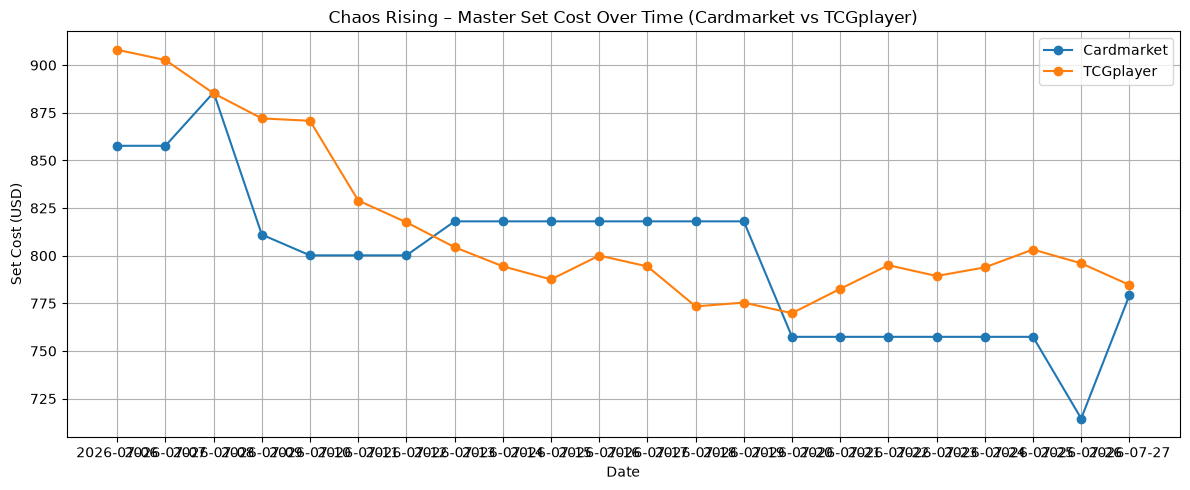

In [ ]:
# Loading dataset
df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# Cardmarket price contribution per card
df["cm_price_component"] = (
    df["cm_avg1"].fillna(0) +
    df["cm_avg1_holo"].fillna(0)
)

# TCGplayer price contribution per card
df["tp_price_component"] = (
    df["tp_normal_marketPrice"].fillna(0) +
    df["tp_holofoil_marketPrice"].fillna(0) +
    df["tp_reverse_holofoil_marketPrice"].fillna(0)
)

# total set cost per day
cm_set_ts = (
    df.groupby("snapshot_date")["cm_price_component"]
      .sum()
      .sort_index()
)

tp_set_ts = (
    df.groupby("snapshot_date")["tp_price_component"]
      .sum()
      .sort_index()
)

# Plot both time series together
plt.figure(figsize=(12, 5))
plt.plot(cm_set_ts.index, cm_set_ts.values, marker="o", label="Cardmarket")
plt.plot(tp_set_ts.index, tp_set_ts.values, marker="o", label="TCGplayer")

plt.title("Chaos Rising – Master Set Cost Over Time (Cardmarket vs TCGplayer)")
plt.xlabel("Date")
plt.ylabel("Set Cost (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
def plot_set_and_rarity_trends(csv_path, source="tp", period=3):
    """
    Plot total set price trend (full-width) and rarity-level trends (4x2 grid)
    using either Cardmarket ("cm") or TCGplayer ("tp") pricing.

    Parameters
    ----------
    csv_path : str
        Path to the cleaned combined CSV file.
    source : str
        "cm" for Cardmarket prices, "tp" for TCGplayer prices.
    period : int
        Seasonal decomposition period (controls trend smoothing).
        Example: 3 (light smoothing), 7 (weekly), 14 (biweekly), 30 (monthly).
    """

    # --- Load dataset ---
    df = pd.read_csv(csv_path)

    # Count printings per rarity by collapsing to unique cards first
    card_printings = (
        df.groupby(["rarity", "id"])
        .agg({
            "cm_avg1": "max",
            "cm_avg1_holo": "max"
        })
    )

    # Now count printings per card
    card_printings["n_printings"] = (
        card_printings["cm_avg1"].notna().astype(int) +
        card_printings["cm_avg1_holo"].notna().astype(int)
    )

    # Finally sum printings per rarity
    rarity_counts = (
        card_printings.groupby("rarity")["n_printings"]
                    .sum()
                    .to_dict()
    )

    # --- Select price source ---
    if source == "cm":
        df["set_price_component"] = (
            df["cm_avg1"].fillna(0) +
            df["cm_avg1_holo"].fillna(0)
        )
        title_prefix = "Cardmarket"
    elif source == "tp":
        df["set_price_component"] = (
            df["tp_normal_marketPrice"].fillna(0) +
            df["tp_holofoil_marketPrice"].fillna(0) +
            df["tp_reverse_holofoil_marketPrice"].fillna(0)
        )
        title_prefix = "TCGplayer"
    else:
        raise ValueError("source must be 'cm' or 'tp'")

    # --- Total set cost per day ---
    set_ts = (
        df.groupby("snapshot_date")["set_price_component"]
          .sum()
          .sort_index()
    )

    # --- Decompose total set price ---
    decomp = seasonal_decompose(set_ts, model="additive", period=period)

    # --- Rarity-level time series ---
    rarity_ts = (
        df.groupby(["snapshot_date", "rarity"])["set_price_component"]
          .sum()
          .unstack(fill_value=0)
          .sort_index()
    )

    # --- Rarity trends ---
    rarity_trends = {}
    for rarity in rarity_ts.columns:
        series = rarity_ts[rarity]
        if series.sum() == 0:
            continue
        decomp_r = seasonal_decompose(series, model="additive", period=period)
        rarity_trends[rarity] = decomp_r.trend

    # --- Economic importance ---
    importance = {r: trend.sum() for r, trend in rarity_trends.items()}
    total_importance = sum(importance.values())
    importance_pct = {r: (importance[r] / total_importance) * 100
                      for r in importance}

    # --- Sort rarities by importance ---
    rarities = sorted(
        rarity_trends.keys(),
        key=lambda r: importance[r],
        reverse=True
    )

    # --- Plot layout ---
    rows, cols = 5, 2
    plt.figure(figsize=(16, 22))

    # --- Row 1: Total set trend (full width) ---
    ax_total = plt.subplot(rows, 1, 1)
    ax_total.plot(decomp.trend.index, decomp.trend.values,
                  linewidth=3, color="orange")
    ax_total.set_title(f"Master Set Price Trend ({title_prefix})", fontsize=16)
    ax_total.set_xlabel("Date")
    ax_total.set_ylabel("Set Cost (USD)")
    ax_total.grid(True)

    # --- Rarity trends (rows 2–5) ---
    start_index = 3  # first rarity subplot index

    for i, rarity in enumerate(rarities):
        trend = rarity_trends[rarity]
        ax = plt.subplot(rows, cols, start_index + i)

        ax.plot(trend.index, trend.values, linewidth=2)

        pct = importance_pct[rarity]
        count = rarity_counts.get(rarity, 0)

        ax.set_title(
            f"{rarity} trend (n={count})\nImportance: {pct:.2f}%",
            fontsize=12
        )

        # Month-day formatting
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())

        ax.set_xlabel("Month-Day")
        ax.set_ylabel("Contribution (USD)")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


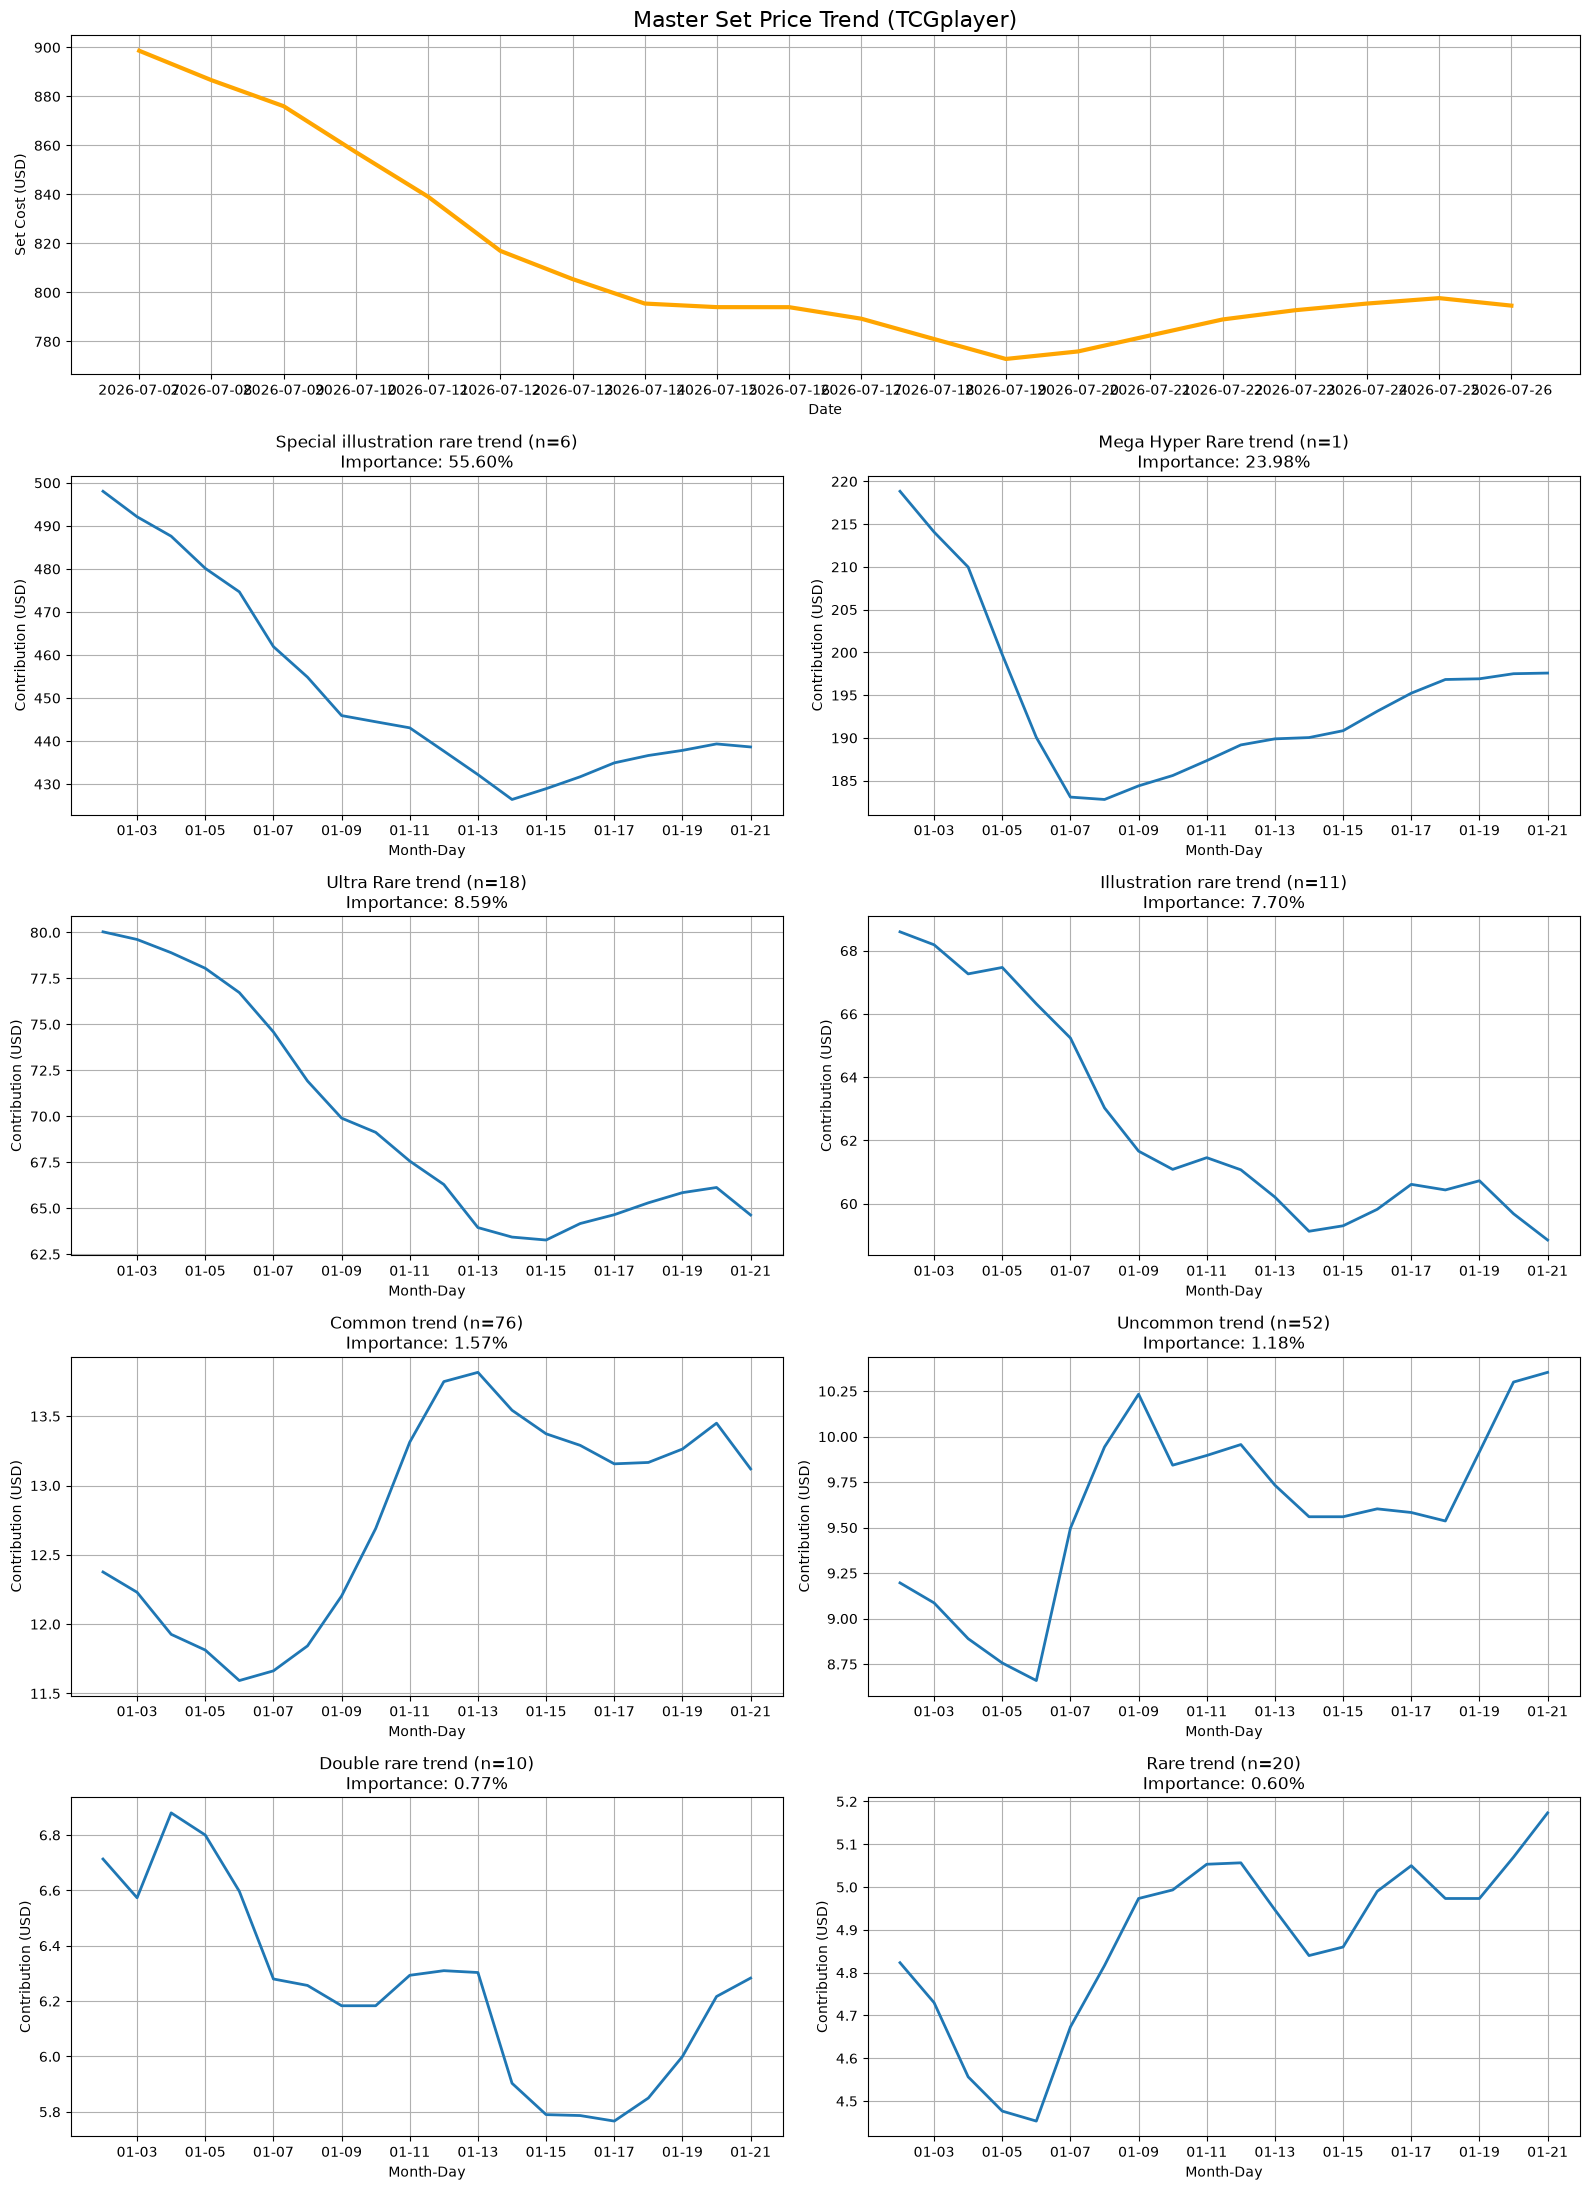

In [4]:
plot_set_and_rarity_trends("../data/chaos_rising_combined_clean.csv", source="tp", period=3)